# Segment-Specific Product Association and Bundling

**Module:** IT3091 – Machine Learning  
**Group:** 2026-DS-10  
**Responsible member:** Senaratne P.A.R.T. (IT24103526)  
**Random seed:** 42  

## Objectives

1. Validate the merchandise basket and customer-segment inputs.
2. Construct invoice-level product baskets.
3. Analyse basket eligibility and product frequency.
4. Mine frequent itemsets using FP-Growth.
5. Generate association rules using support, confidence and lift.
6. Compare overall and segment-specific product associations.
7. Evaluate rule robustness, coverage and business usefulness.
8. Produce evidence-based cross-selling and bundle recommendations.

Administrative StockCodes, cancellations, returns, invalid purchases and exact duplicate rows were excluded during preprocessing. No additional statistical outlier deletion is performed.

In [5]:
from pathlib import Path
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import fpgrowth, association_rules

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")

print("Libraries imported successfully.")
print("Random seed:", RANDOM_STATE)

Libraries imported successfully.
Random seed: 42


In [6]:
def locate_project_root(start_path=None):
    current_path = Path(start_path or Path.cwd()).resolve()

    for candidate_path in [current_path, *current_path.parents]:
        if (
            (candidate_path / "data").exists()
            and (candidate_path / "notebooks").exists()
        ):
            return candidate_path

    raise FileNotFoundError(
        "Project root could not be located. "
        "Open the notebook from the project repository."
    )


PROJECT_ROOT = locate_project_root()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DOCUMENTATION_DIR = PROJECT_ROOT / "documentation"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

basket_path = (
    PROCESSED_DIR
    / "merchandise_basket_transactions.csv"
)

segment_assignment_path = (
    PROCESSED_DIR
    / "customer_segment_assignments.csv"
)

required_files = [
    basket_path,
    segment_assignment_path,
]

missing_files = [
    str(file_path)
    for file_path in required_files
    if not file_path.exists()
]

assert not missing_files, (
    "Required input files are missing:\n"
    + "\n".join(missing_files)
)

print("Project root:", PROJECT_ROOT)
print("Basket transactions:", basket_path.exists())
print("Segment assignments:", segment_assignment_path.exists())

Project root: /Users/lakshithadilshan/Documents/online-retail-customer-analytics
Basket transactions: True
Segment assignments: True


In [ ]:
def calculate_sha256(file_path, chunk_size=8192):
    sha256_hash = hashlib.sha256()

    with open(file_path, "rb") as input_file:
        while True:
            data_chunk = input_file.read(chunk_size)

            if not data_chunk:
                break

            sha256_hash.update(data_chunk)

    return sha256_hash.hexdigest()


input_fingerprints = pd.DataFrame([
    {
        "Dataset": "Merchandise Basket Transactions",
        "Filename": basket_path.name,
        "File_Size_MB": basket_path.stat().st_size / (1024 ** 2),
        "SHA256": calculate_sha256(basket_path),
        "Source_Member": "Lakshitha Dilshan J.K.P. (IT24102621)",
        "Purpose": "Clean positive merchandise transactions",
    },
    {
        "Dataset": "Customer Segment Assignments",
        "Filename": segment_assignment_path.name,
        "File_Size_MB": (
            segment_assignment_path.stat().st_size
            / (1024 ** 2)
        ),
        "SHA256": calculate_sha256(
            segment_assignment_path
        ),
        "Source_Member": "Palliyaguruge C.T. (IT24103655)",
        "Purpose": "Final customer cluster and segment labels",
    },
])

assert input_fingerprints["SHA256"].str.len().eq(64).all()
assert input_fingerprints["SHA256"].is_unique

print("Input fingerprint evidence created.")
display(input_fingerprints)

All input fingerprints matched.


,Input,Filename,Expected_SHA256,Actual_SHA256,Fingerprint_Match
0,Merchandise basket transactions,merchandise_basket_transactions.csv,eab4454dad49c122483dcc07ff67db16a770d2dd53acc0c58c7425dbb3fca9ca,eab4454dad49c122483dcc07ff67db16a770d2dd53acc0c58c7425dbb3fca9ca,True
1,Customer segment assignments,customer_segment_assignments.csv,8753493be4c5ab3c79262530ad86805430f76605208e28bedef1e549f693a854,8753493be4c5ab3c79262530ad86805430f76605208e28bedef1e549f693a854,True


In [8]:
basket_transactions = pd.read_csv(
    basket_path,
    dtype={
        "InvoiceNo": "string",
        "StockCode": "string",
        "Description": "string",
        "Country": "string",
    },
    parse_dates=["InvoiceDate"],
)

segment_assignments = pd.read_csv(
    segment_assignment_path,
    dtype={
        "CustomerID": "int64",
        "Cluster": "int64",
        "Segment": "string",
        "PrimaryCountry": "string",
    },
)

basket_transactions["CustomerID"] = pd.to_numeric(
    basket_transactions["CustomerID"],
    errors="coerce",
).astype("Int64")

# Transaction validation
assert len(basket_transactions) == 522568
assert basket_transactions["InvoiceNo"].nunique() == 19773
assert basket_transactions["InvoiceNo"].notna().all()
assert basket_transactions["StockCode"].notna().all()
assert basket_transactions["StockCode"].nunique() > 1
assert basket_transactions["Description"].notna().all()
assert basket_transactions["InvoiceDate"].notna().all()
assert (basket_transactions["Quantity"] > 0).all()
assert (basket_transactions["UnitPrice"] > 0).all()

# Segment-assignment validation
assert len(segment_assignments) == 4334
assert segment_assignments["CustomerID"].is_unique
assert segment_assignments["Segment"].nunique() == 5
assert segment_assignments.isna().sum().sum() == 0

identified_basket_transactions = (
    basket_transactions.loc[
        basket_transactions["CustomerID"].notna()
    ]
    .copy()
)

identified_basket_transactions["CustomerID"] = (
    identified_basket_transactions["CustomerID"]
    .astype("int64")
)

segment_transactions = (
    identified_basket_transactions
    .merge(
        segment_assignments[
            ["CustomerID", "Cluster", "Segment"]
        ],
        on="CustomerID",
        how="inner",
        validate="many_to_one",
    )
)

# Joined-data validation
assert len(segment_transactions) == 391150
assert segment_transactions["CustomerID"].nunique() == 4334
assert segment_transactions["InvoiceNo"].nunique() == 18402
assert segment_transactions["Segment"].notna().all()
assert segment_transactions["Segment"].nunique() == 5

actual_product_count = (
    basket_transactions["StockCode"].nunique()
)

print("Association-mining input quality checks passed.")
print(
    "Overall merchandise rows:",
    f"{len(basket_transactions):,}",
)
print(
    "Overall merchandise invoices:",
    f"{basket_transactions['InvoiceNo'].nunique():,}",
)
print(
    "Unique merchandise StockCodes:",
    f"{actual_product_count:,}",
)
print(
    "Segment-specific rows:",
    f"{len(segment_transactions):,}",
)
print(
    "Segment-specific invoices:",
    f"{segment_transactions['InvoiceNo'].nunique():,}",
)
print(
    "Assigned customers:",
    f"{segment_transactions['CustomerID'].nunique():,}",
)

display(
    segment_assignments["Segment"]
    .value_counts()
    .rename_axis("Segment")
    .reset_index(name="Customers")
)

Association-mining input quality checks passed.
Overall merchandise rows: 522,568
Overall merchandise invoices: 19,773
Unique merchandise StockCodes: 3,803
Segment-specific rows: 391,150
Segment-specific invoices: 18,402
Assigned customers: 4,334


,Segment,Customers
0,Hibernating Low Value,1136
1,At Risk Regular,1006
2,Loyal High Value,965
3,Recent Low Engagement,869
4,Champions,358


In [9]:
segment_transaction_summary = (
    segment_transactions
    .groupby(
        ["Cluster", "Segment"],
        observed=True,
    )
    .agg(
        Customers=("CustomerID", "nunique"),
        Invoices=("InvoiceNo", "nunique"),
        Transaction_Rows=("StockCode", "size"),
        Unique_Products=("StockCode", "nunique"),
        Total_Units=("Quantity", "sum"),
    )
    .reset_index()
)

segment_transaction_summary[
    "Average_Products_Per_Invoice"
] = (
    segment_transaction_summary["Transaction_Rows"]
    / segment_transaction_summary["Invoices"]
)

segment_transaction_summary[
    "Invoice_Percentage"
] = (
    segment_transaction_summary["Invoices"]
    / segment_transaction_summary["Invoices"].sum()
    * 100
)

assert len(segment_transaction_summary) == 5
assert (
    segment_transaction_summary["Invoices"] > 0
).all()

print("Segment-level transaction summary created.")
display(
    segment_transaction_summary.sort_values("Cluster")
)

Segment-level transaction summary created.


,Cluster,Segment,Customers,Invoices,Transaction_Rows,Unique_Products,Total_Units,Average_Products_Per_Invoice,Invoice_Percentage
0,1,Hibernating Low Value,1136,1365,22007,2871,184779,16.1223,7.4177
1,2,Recent Low Engagement,869,1364,28637,2852,207688,20.9949,7.4122
2,3,At Risk Regular,1006,3073,67915,3171,871305,22.1006,16.6993
3,4,Loyal High Value,965,5417,125011,3318,1223341,23.0775,29.4370
4,5,Champions,358,7183,147580,3367,2654671,20.5457,39.0338


## Invoice-Level Basket Construction

Each row of a basket matrix represents one invoice, while each column represents a unique product (`StockCode`). A value of `True` indicates that the product appeared in the invoice.

Binary product presence is used instead of quantity because association-rule mining evaluates whether products occur together. Duplicate occurrences of the same product within an invoice are therefore collapsed into a single presence indicator.

Sparse matrices are used to reduce memory consumption because most invoices contain only a small subset of all available products.

In [10]:
product_description_lookup = (
    segment_transactions[
        ["StockCode", "Description"]
    ]
    .dropna()
    .assign(
        Description=lambda data: (
            data["Description"]
            .str.strip()
            .str.replace(r"\s+", " ", regex=True)
        )
    )
    .groupby("StockCode")["Description"]
    .agg(
        lambda descriptions: (
            descriptions.value_counts().index[0]
        )
    )
    .to_dict()
)

assert len(product_description_lookup) > 0

print(
    "Product descriptions available:",
    f"{len(product_description_lookup):,}",
)

display(
    pd.DataFrame(
        list(product_description_lookup.items()),
        columns=["StockCode", "Description"],
    ).head(10)
)

Product descriptions available: 3,659


,StockCode,Description
0,10002,INFLATABLE POLITICAL GLOBE
1,10080,GROOVY CACTUS INFLATABLE
2,10120,DOGGY RUBBER
3,10123C,HEARTS WRAPPING TAPE
4,10124A,SPOTS ON RED BOOKCOVER TAPE
5,10124G,ARMY CAMO BOOKCOVER TAPE
6,10125,MINI FUNKY DESIGN TAPES
7,10133,COLOURING PENCILS BROWN TUBE
8,10135,COLOURING PENCILS BROWN TUBE
9,11001,ASSTD DESIGN RACING CAR PEN


In [13]:
from scipy.sparse import csr_matrix


def create_sparse_basket(transaction_data):
    invoice_product_pairs = (
        transaction_data[
            ["InvoiceNo", "StockCode"]
        ]
        .dropna()
        .drop_duplicates()
        .copy()
    )

    invoice_codes, invoice_labels = pd.factorize(
        invoice_product_pairs["InvoiceNo"],
        sort=True,
    )

    product_codes, product_labels = pd.factorize(
        invoice_product_pairs["StockCode"],
        sort=True,
    )

    basket_matrix = csr_matrix(
        (
            np.ones(
                len(invoice_product_pairs),
                dtype=bool,
            ),
            (invoice_codes, product_codes),
        ),
        shape=(
            len(invoice_labels),
            len(product_labels),
        ),
        dtype=bool,
    )

    basket_dataframe = pd.DataFrame.sparse.from_spmatrix(
        basket_matrix,
        index=pd.Index(
            invoice_labels,
            name="InvoiceNo",
        ),
        columns=pd.Index(
            product_labels,
            name="StockCode",
        ),
    )

    return basket_dataframe


segment_baskets = {}
basket_quality_records = []

for segment_name, segment_data in (
    segment_transactions.groupby(
        "Segment",
        observed=True,
    )
):
    basket = create_sparse_basket(segment_data)

    assert basket.index.is_unique
    assert basket.columns.is_unique
    assert basket.shape[0] == (
        segment_data["InvoiceNo"].nunique()
    )
    assert basket.shape[1] == (
        segment_data["StockCode"].nunique()
    )
    assert basket.sparse.density > 0
    assert basket.sparse.density < 1

    segment_baskets[segment_name] = basket

    unique_invoice_product_pairs = int(
    basket.sparse.to_coo().nnz
)

    basket_quality_records.append({
        "Segment": segment_name,
        "Invoices": basket.shape[0],
        "Products": basket.shape[1],
        "Invoice_Product_Pairs": (
            unique_invoice_product_pairs
        ),
        "Basket_Density_Percentage": (
            basket.sparse.density * 100
        ),
        "Average_Unique_Products_Per_Invoice": (
            unique_invoice_product_pairs
            / basket.shape[0]
        ),
    })

basket_quality_summary = (
    pd.DataFrame(basket_quality_records)
    .sort_values("Invoices")
    .reset_index(drop=True)
)

assert len(segment_baskets) == 5
assert len(basket_quality_summary) == 5

print(
    "Sparse basket matrices created:",
    len(segment_baskets),
)

display(basket_quality_summary)

Sparse basket matrices created: 5


,Segment,Invoices,Products,Invoice_Product_Pairs,Basket_Density_Percentage,Average_Unique_Products_Per_Invoice
0,Recent Low Engagement,1364,2852,27966,0.7189,20.5029
1,Hibernating Low Value,1365,2871,21723,0.5543,15.9143
2,At Risk Regular,3073,3171,67141,0.6890,21.8487
3,Loyal High Value,5417,3318,123212,0.6855,22.7454
4,Champions,7183,3367,146284,0.6049,20.3653


## Frequent-Itemset Mining Strategy

FP-Growth is applied separately to each customer segment.

A segment-adaptive minimum-support threshold is used:

\[
\text{Minimum Support}
=
\max\left(0.01,\frac{20}{\text{Number of Segment Invoices}}\right)
\]

This requires a product combination to occur in at least 1% of segment invoices and, for smaller segments, in at least approximately 20 invoices. This approach reduces unreliable rules caused by very small occurrence counts while allowing fair analysis across segments of different sizes.

Frequent itemsets are limited to a maximum length of three products to maintain computational efficiency and business interpretability.

In [14]:
MINIMUM_OCCURRENCES = 20
MINIMUM_SUPPORT_FLOOR = 0.01
MAXIMUM_ITEMSET_LENGTH = 3

frequent_itemsets_by_segment = {}
itemset_summary_records = []

for segment_name, basket in segment_baskets.items():
    invoice_count = basket.shape[0]

    minimum_support = max(
        MINIMUM_SUPPORT_FLOOR,
        MINIMUM_OCCURRENCES / invoice_count,
    )

    frequent_itemsets = fpgrowth(
        basket,
        min_support=minimum_support,
        use_colnames=True,
        max_len=MAXIMUM_ITEMSET_LENGTH,
    )

    frequent_itemsets["Itemset_Length"] = (
        frequent_itemsets["itemsets"].apply(len)
    )

    frequent_itemsets["Support_Count"] = (
        frequent_itemsets["support"]
        * invoice_count
    ).round().astype("int64")

    frequent_itemsets["Segment"] = segment_name
    frequent_itemsets["Minimum_Support"] = (
        minimum_support
    )

    frequent_itemsets = (
        frequent_itemsets.sort_values(
            ["Itemset_Length", "support"],
            ascending=[True, False],
        )
        .reset_index(drop=True)
    )

    frequent_itemsets_by_segment[
        segment_name
    ] = frequent_itemsets

    itemset_summary_records.append({
        "Segment": segment_name,
        "Invoices": invoice_count,
        "Minimum_Support": minimum_support,
        "Approximate_Minimum_Occurrences": int(
            np.ceil(minimum_support * invoice_count)
        ),
        "Frequent_One_Itemsets": int(
            (
                frequent_itemsets["Itemset_Length"] == 1
            ).sum()
        ),
        "Frequent_Two_Itemsets": int(
            (
                frequent_itemsets["Itemset_Length"] == 2
            ).sum()
        ),
        "Frequent_Three_Itemsets": int(
            (
                frequent_itemsets["Itemset_Length"] == 3
            ).sum()
        ),
        "Total_Frequent_Itemsets": len(
            frequent_itemsets
        ),
    })

frequent_itemset_summary = (
    pd.DataFrame(itemset_summary_records)
    .sort_values("Invoices")
    .reset_index(drop=True)
)

assert len(frequent_itemset_summary) == 5

print("Segment-specific FP-Growth completed.")
display(frequent_itemset_summary)

Segment-specific FP-Growth completed.


,Segment,Invoices,Minimum_Support,Approximate_Minimum_Occurrences,Frequent_One_Itemsets,Frequent_Two_Itemsets,Frequent_Three_Itemsets,Total_Frequent_Itemsets
0,Recent Low Engagement,1364,0.0147,20,404,46,1,451
1,Hibernating Low Value,1365,0.0147,20,227,17,4,248
2,At Risk Regular,3073,0.0100,31,694,400,56,1150
3,Loyal High Value,5417,0.0100,55,694,439,161,1294
4,Champions,7183,0.0100,72,571,564,237,1372


## Association-Rule Generation and Quality Filtering

Rules are generated from the segment-specific frequent itemsets using the following criteria:

- **Confidence ≥ 0.30:** At least 30% of invoices containing the antecedent also contain the consequent.
- **Lift ≥ 1.20:** The products occur together at least 20% more frequently than expected under independence.
- **Consequent length = 1:** Each rule recommends one clear target product.
- **Antecedent length ≤ 2:** Rules remain understandable and operationally useful.
- **Minimum occurrence requirement:** Already enforced during frequent-itemset mining.

Support measures prevalence, confidence measures conditional reliability, and lift measures association strength relative to chance. A high confidence value alone is insufficient because a commonly purchased consequent can produce misleading rules; therefore, lift is also required.

In [15]:
MINIMUM_CONFIDENCE = 0.30
MINIMUM_LIFT = 1.20

rules_by_segment = {}
rule_summary_records = []
all_rule_frames = []


def format_stockcodes(itemset):
    return ", ".join(
        sorted(str(code) for code in itemset)
    )


def format_descriptions(itemset):
    descriptions = [
        product_description_lookup.get(
            str(code),
            f"Unknown product ({code})",
        )
        for code in sorted(
            itemset,
            key=lambda value: str(value),
        )
    ]

    return " + ".join(descriptions)


for segment_name, frequent_itemsets in (
    frequent_itemsets_by_segment.items()
):
    invoice_count = segment_baskets[
        segment_name
    ].shape[0]

    if frequent_itemsets.empty:
        generated_rules = pd.DataFrame()
    else:
        generated_rules = association_rules(
            frequent_itemsets[
                ["support", "itemsets"]
            ],
            metric="confidence",
            min_threshold=MINIMUM_CONFIDENCE,
        )

    total_generated_rules = len(generated_rules)

    if not generated_rules.empty:
        generated_rules["Antecedent_Length"] = (
            generated_rules["antecedents"].apply(len)
        )

        generated_rules["Consequent_Length"] = (
            generated_rules["consequents"].apply(len)
        )

        filtered_rules = (
            generated_rules.loc[
                (
                    generated_rules["lift"]
                    >= MINIMUM_LIFT
                )
                & (
                    generated_rules[
                        "Antecedent_Length"
                    ] <= 2
                )
                & (
                    generated_rules[
                        "Consequent_Length"
                    ] == 1
                )
            ]
            .copy()
        )

        filtered_rules["Segment"] = segment_name
        filtered_rules["Invoice_Count"] = (
            invoice_count
        )

        filtered_rules["Support_Count"] = (
            filtered_rules["support"]
            * invoice_count
        ).round().astype("int64")

        filtered_rules["Antecedent_StockCodes"] = (
            filtered_rules["antecedents"].apply(
                format_stockcodes
            )
        )

        filtered_rules["Consequent_StockCodes"] = (
            filtered_rules["consequents"].apply(
                format_stockcodes
            )
        )

        filtered_rules["Antecedent_Products"] = (
            filtered_rules["antecedents"].apply(
                format_descriptions
            )
        )

        filtered_rules["Consequent_Products"] = (
            filtered_rules["consequents"].apply(
                format_descriptions
            )
        )

        filtered_rules["Rule"] = (
            filtered_rules["Antecedent_Products"]
            + " → "
            + filtered_rules["Consequent_Products"]
        )

        filtered_rules = (
            filtered_rules.sort_values(
                ["lift", "confidence", "support"],
                ascending=[False, False, False],
            )
            .reset_index(drop=True)
        )
    else:
        filtered_rules = generated_rules.copy()

    rules_by_segment[segment_name] = filtered_rules

    if not filtered_rules.empty:
        all_rule_frames.append(filtered_rules)

    rule_summary_records.append({
        "Segment": segment_name,
        "Invoices": invoice_count,
        "Generated_Rules": total_generated_rules,
        "Retained_Rules": len(filtered_rules),
        "Median_Support": (
            filtered_rules["support"].median()
            if not filtered_rules.empty
            else np.nan
        ),
        "Median_Confidence": (
            filtered_rules["confidence"].median()
            if not filtered_rules.empty
            else np.nan
        ),
        "Median_Lift": (
            filtered_rules["lift"].median()
            if not filtered_rules.empty
            else np.nan
        ),
        "Maximum_Lift": (
            filtered_rules["lift"].max()
            if not filtered_rules.empty
            else np.nan
        ),
    })

rule_quality_summary = (
    pd.DataFrame(rule_summary_records)
    .sort_values("Invoices")
    .reset_index(drop=True)
)

if all_rule_frames:
    all_segment_rules = pd.concat(
        all_rule_frames,
        ignore_index=True,
    )
else:
    all_segment_rules = pd.DataFrame()

assert len(rule_quality_summary) == 5

print(
    "Association-rule generation completed."
)

print(
    "Total retained rules:",
    f"{len(all_segment_rules):,}",
)

display(rule_quality_summary)

Association-rule generation completed.
Total retained rules: 3,129


,Segment,Invoices,Generated_Rules,Retained_Rules,Median_Support,Median_Confidence,Median_Lift,Maximum_Lift
0,Recent Low Engagement,1364,88,85,0.0176,0.4776,12.1180,35.7238
1,Hibernating Low Value,1365,47,38,0.0187,0.6886,13.8146,26.7148
2,At Risk Regular,3073,790,693,0.0124,0.5333,14.4199,72.6723
3,Loyal High Value,5417,1156,1072,0.0129,0.5140,9.9981,70.0420
4,Champions,7183,1310,1241,0.0128,0.5000,8.8143,53.8135


In [16]:
TOP_RULES_PER_SEGMENT = 10

top_rules_by_segment = (
    all_segment_rules
    .sort_values(
        [
            "Segment",
            "lift",
            "confidence",
            "support",
        ],
        ascending=[True, False, False, False],
    )
    .groupby(
        "Segment",
        observed=True,
        group_keys=False,
    )
    .head(TOP_RULES_PER_SEGMENT)
    .reset_index(drop=True)
)

display_columns = [
    "Segment",
    "Rule",
    "Support_Count",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction",
]

print(
    "Top rules displayed:",
    len(top_rules_by_segment),
)

display(
    top_rules_by_segment[display_columns]
)

Top rules displayed: 50


,Segment,Rule,Support_Count,support,confidence,lift,leverage,conviction
0,At Risk Regular,HERB MARKER PARSLEY + HERB MARKER CHIVES → HERB MARKER ROSEMARY,35,0.0114,0.9459,72.6723,0.0112,18.2592
1,At Risk Regular,HERB MARKER THYME + HERB MARKER CHIVES → HERB MARKER ROSEMARY,35,0.0114,0.9459,72.6723,0.0112,18.2592
2,At Risk Regular,HERB MARKER MINT + HERB MARKER CHIVES → HERB MARKER ROSEMARY,34,0.0111,0.9444,72.5569,0.0109,17.7657
3,At Risk Regular,HERB MARKER BASIL + HERB MARKER CHIVES → HERB MARKER ROSEMARY,34,0.0111,0.9444,72.5569,0.0109,17.7657
4,At Risk Regular,HERB MARKER THYME + HERB MARKER PARSLEY → HERB MARKER ROSEMARY,39,0.0127,0.9286,71.3375,0.0125,13.8178
5,At Risk Regular,HERB MARKER THYME + HERB MARKER BASIL → HERB MARKER ROSEMARY,38,0.0124,0.9268,71.2037,0.0122,13.4888
6,At Risk Regular,HERB MARKER THYME + HERB MARKER MINT → HERB MARKER ROSEMARY,38,0.0124,0.9268,71.2037,0.0122,13.4888
7,At Risk Regular,HERB MARKER ROSEMARY → HERB MARKER THYME,40,0.0130,1.0000,69.8409,0.0128,inf
8,At Risk Regular,HERB MARKER ROSEMARY + HERB MARKER PARSLEY → HERB MARKER THYME,39,0.0127,1.0000,69.8409,0.0125,inf
9,At Risk Regular,HERB MARKER ROSEMARY + HERB MARKER BASIL → HERB MARKER THYME,38,0.0124,1.0000,69.8409,0.0122,inf


## Practical Rule Prioritisation

The initial filtering produced a large set of statistically valid rules. A second-stage practical filter is therefore applied:

- Support count ≥ 25 invoices
- Confidence ≥ 0.40
- Lift ≥ 1.50
- Positive leverage
- Finite and valid metric values

Rules are ranked within each segment using percentile ranks for support, confidence, lift, and leverage. The composite score gives balanced importance to prevalence, reliability, association strength, and improvement over independence:

\[
\text{Rule Score}
=
0.30(\text{Support Rank})
+
0.30(\text{Confidence Rank})
+
0.25(\text{Lift Rank})
+
0.15(\text{Leverage Rank})
\]

This prevents extremely rare high-lift rules from automatically outranking more reliable and commercially useful product relationships.

In [17]:
PRACTICAL_MINIMUM_SUPPORT_COUNT = 25
PRACTICAL_MINIMUM_CONFIDENCE = 0.40
PRACTICAL_MINIMUM_LIFT = 1.50

practical_rules = (
    all_segment_rules.loc[
        (
            all_segment_rules["Support_Count"]
            >= PRACTICAL_MINIMUM_SUPPORT_COUNT
        )
        & (
            all_segment_rules["confidence"]
            >= PRACTICAL_MINIMUM_CONFIDENCE
        )
        & (
            all_segment_rules["lift"]
            >= PRACTICAL_MINIMUM_LIFT
        )
        & (
            all_segment_rules["leverage"] > 0
        )
        & np.isfinite(
            all_segment_rules["support"]
        )
        & np.isfinite(
            all_segment_rules["confidence"]
        )
        & np.isfinite(
            all_segment_rules["lift"]
        )
        & np.isfinite(
            all_segment_rules["leverage"]
        )
    ]
    .copy()
)

practical_rules["Support_Rank"] = (
    practical_rules
    .groupby("Segment")["support"]
    .rank(pct=True)
)

practical_rules["Confidence_Rank"] = (
    practical_rules
    .groupby("Segment")["confidence"]
    .rank(pct=True)
)

practical_rules["Lift_Rank"] = (
    practical_rules
    .groupby("Segment")["lift"]
    .rank(pct=True)
)

practical_rules["Leverage_Rank"] = (
    practical_rules
    .groupby("Segment")["leverage"]
    .rank(pct=True)
)

practical_rules["Rule_Score"] = (
    0.30 * practical_rules["Support_Rank"]
    + 0.30 * practical_rules["Confidence_Rank"]
    + 0.25 * practical_rules["Lift_Rank"]
    + 0.15 * practical_rules["Leverage_Rank"]
)

practical_rules = (
    practical_rules
    .sort_values(
        [
            "Segment",
            "Rule_Score",
            "confidence",
            "lift",
        ],
        ascending=[True, False, False, False],
    )
    .reset_index(drop=True)
)

practical_rule_summary = (
    practical_rules
    .groupby("Segment", observed=True)
    .agg(
        Practical_Rules=("Rule", "size"),
        Median_Support_Count=(
            "Support_Count",
            "median",
        ),
        Median_Confidence=(
            "confidence",
            "median",
        ),
        Median_Lift=("lift", "median"),
        Maximum_Rule_Score=(
            "Rule_Score",
            "max",
        ),
    )
    .reset_index()
)

assert practical_rules["Rule_Score"].between(
    0,
    1,
).all()

print(
    "Practical rules retained:",
    f"{len(practical_rules):,}",
)

display(practical_rule_summary)

Practical rules retained: 2,361


,Segment,Practical_Rules,Median_Support_Count,Median_Confidence,Median_Lift,Maximum_Rule_Score
0,At Risk Regular,550,37.0000,0.5860,18.8331,0.8566
1,Champions,927,91.0000,0.5513,9.4065,0.9539
2,Hibernating Low Value,19,30.0000,0.6944,12.7703,0.8368
3,Loyal High Value,839,69.0000,0.5586,10.7165,0.9182
4,Recent Low Engagement,26,31.5000,0.5703,12.9218,0.8135


In [20]:
TOP_RECOMMENDATIONS_PER_SEGMENT = 8


def select_diverse_rules(
    segment_name,
    segment_rule_data,
):
    selected_rows = []
    selected_consequents = set()

    ordered_rules = (
        segment_rule_data
        .sort_values(
            [
                "Rule_Score",
                "confidence",
                "lift",
                "support",
            ],
            ascending=[
                False,
                False,
                False,
                False,
            ],
        )
    )

    for _, rule_row in ordered_rules.iterrows():
        consequent_key = (
            rule_row["Consequent_StockCodes"]
        )

        if consequent_key in selected_consequents:
            continue

        selected_rule = rule_row.copy()
        selected_rule["Segment"] = segment_name

        selected_rows.append(selected_rule)
        selected_consequents.add(consequent_key)

        if (
            len(selected_rows)
            >= TOP_RECOMMENDATIONS_PER_SEGMENT
        ):
            break

    return pd.DataFrame(selected_rows)


selected_segment_frames = []

for segment_name, segment_rule_data in (
    practical_rules.groupby(
        "Segment",
        observed=True,
    )
):
    selected_segment_rules = select_diverse_rules(
        segment_name,
        segment_rule_data,
    )

    if not selected_segment_rules.empty:
        selected_segment_frames.append(
            selected_segment_rules
        )

selected_recommendation_rules = pd.concat(
    selected_segment_frames,
    ignore_index=True,
)

selected_recommendation_rules[
    "Recommendation_Rank"
] = (
    selected_recommendation_rules
    .groupby("Segment")["Rule_Score"]
    .rank(
        method="first",
        ascending=False,
    )
    .astype("int64")
)

selected_recommendation_rules = (
    selected_recommendation_rules
    .sort_values(
        ["Segment", "Recommendation_Rank"]
    )
    .reset_index(drop=True)
)

recommendation_count_by_segment = (
    selected_recommendation_rules
    .groupby("Segment")
    .size()
)

assert (
    recommendation_count_by_segment
    <= TOP_RECOMMENDATIONS_PER_SEGMENT
).all()

assert (
    selected_recommendation_rules[
        ["Segment", "Consequent_StockCodes"]
    ]
    .duplicated()
    .sum()
    == 0
)

print(
    "Diverse recommendation rules selected:",
    len(selected_recommendation_rules),
)

display(
    recommendation_count_by_segment
    .rename("Selected_Rules")
    .reset_index()
)

display(
    selected_recommendation_rules[
        [
            "Segment",
            "Recommendation_Rank",
            "Rule",
            "Support_Count",
            "support",
            "confidence",
            "lift",
            "leverage",
            "Rule_Score",
        ]
    ]
)

Diverse recommendation rules selected: 40


,Segment,Selected_Rules
0,At Risk Regular,8
1,Champions,8
2,Hibernating Low Value,8
3,Loyal High Value,8
4,Recent Low Engagement,8


,Segment,Recommendation_Rank,Rule,Support_Count,support,confidence,lift,leverage,Rule_Score
0,At Risk Regular,1,HERB MARKER BASIL → HERB MARKER MINT,43,0.0140,0.9773,66.7369,0.0138,0.8566
1,At Risk Regular,2,HERB MARKER BASIL → HERB MARKER PARSLEY,43,0.0140,0.9773,66.7369,0.0138,0.8566
2,At Risk Regular,3,HERB MARKER PARSLEY + HERB MARKER MINT → HERB MARKER BASIL,42,0.0137,0.9767,68.2167,0.0135,0.8485
3,At Risk Regular,4,PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY TEACUP AND SAUCER → GREEN REGENCY TEACUP AND SAUCER,81,0.0264,0.9205,20.2040,0.0251,0.8390
4,At Risk Regular,5,HERB MARKER ROSEMARY → HERB MARKER THYME,40,0.0130,1.0000,69.8409,0.0128,0.8314
5,At Risk Regular,6,BLUE HAPPY BIRTHDAY BUNTING → PINK HAPPY BIRTHDAY BUNTING,77,0.0251,0.8191,25.9510,0.0241,0.8314
6,At Risk Regular,7,PINK HAPPY BIRTHDAY BUNTING → BLUE HAPPY BIRTHDAY BUNTING,77,0.0251,0.7938,25.9510,0.0241,0.8254
7,At Risk Regular,8,GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY TEACUP AND SAUCER → ROSES REGENCY TEACUP AND SAUCER,81,0.0264,0.8617,18.1371,0.0249,0.8107
8,Champions,1,GREEN REGENCY TEACUP AND SAUCER → ROSES REGENCY TEACUP AND SAUCER,242,0.0337,0.8259,16.9506,0.0317,0.9539
9,Champions,2,PINK REGENCY TEACUP AND SAUCER → GREEN REGENCY TEACUP AND SAUCER,197,0.0274,0.8008,19.6322,0.0260,0.9512


## Support-Threshold Sensitivity Analysis

Association-rule results can change when the minimum-support threshold changes. To evaluate robustness, FP-Growth and rule generation are repeated using four support thresholds:

- 0.008
- 0.010
- 0.0125
- 0.015

The same confidence and lift requirements are maintained. The analysis compares the number and quality of retained rules across thresholds and customer segments.

A useful association pattern should not exist only under one unusually permissive parameter setting. However, rule counts are expected to decrease as minimum support increases because increasingly common product combinations are required.

In [21]:
SUPPORT_THRESHOLDS = [
    0.0080,
    0.0100,
    0.0125,
    0.0150,
]

sensitivity_records = []
sensitivity_rule_store = {}

for segment_name, basket in segment_baskets.items():
    invoice_count = basket.shape[0]

    for support_threshold in SUPPORT_THRESHOLDS:
        sensitivity_itemsets = fpgrowth(
            basket,
            min_support=support_threshold,
            use_colnames=True,
            max_len=MAXIMUM_ITEMSET_LENGTH,
        )

        if sensitivity_itemsets.empty:
            sensitivity_rules = pd.DataFrame()
        else:
            sensitivity_rules = association_rules(
                sensitivity_itemsets,
                metric="confidence",
                min_threshold=(
                    PRACTICAL_MINIMUM_CONFIDENCE
                ),
            )

        if not sensitivity_rules.empty:
            sensitivity_rules[
                "Antecedent_Length"
            ] = (
                sensitivity_rules[
                    "antecedents"
                ].apply(len)
            )

            sensitivity_rules[
                "Consequent_Length"
            ] = (
                sensitivity_rules[
                    "consequents"
                ].apply(len)
            )

            sensitivity_rules["Support_Count"] = (
                sensitivity_rules["support"]
                * invoice_count
            ).round().astype("int64")

            sensitivity_rules = (
                sensitivity_rules.loc[
                    (
                        sensitivity_rules["lift"]
                        >= PRACTICAL_MINIMUM_LIFT
                    )
                    & (
                        sensitivity_rules[
                            "Antecedent_Length"
                        ] <= 2
                    )
                    & (
                        sensitivity_rules[
                            "Consequent_Length"
                        ] == 1
                    )
                    & (
                        sensitivity_rules[
                            "leverage"
                        ] > 0
                    )
                ]
                .copy()
            )

            sensitivity_rules["Segment"] = (
                segment_name
            )

            sensitivity_rules[
                "Support_Threshold"
            ] = support_threshold

            sensitivity_rules["Rule_Key"] = (
                sensitivity_rules.apply(
                    lambda row: (
                        tuple(
                            sorted(
                                str(item)
                                for item
                                in row["antecedents"]
                            )
                        ),
                        tuple(
                            sorted(
                                str(item)
                                for item
                                in row["consequents"]
                            )
                        ),
                    ),
                    axis=1,
                )
            )
        else:
            sensitivity_rules = pd.DataFrame()

        experiment_key = (
            segment_name,
            support_threshold,
        )

        sensitivity_rule_store[
            experiment_key
        ] = sensitivity_rules

        sensitivity_records.append({
            "Segment": segment_name,
            "Support_Threshold": (
                support_threshold
            ),
            "Minimum_Invoice_Count": int(
                np.ceil(
                    support_threshold
                    * invoice_count
                )
            ),
            "Frequent_Itemsets": len(
                sensitivity_itemsets
            ),
            "Retained_Rules": len(
                sensitivity_rules
            ),
            "Median_Confidence": (
                sensitivity_rules[
                    "confidence"
                ].median()
                if not sensitivity_rules.empty
                else np.nan
            ),
            "Median_Lift": (
                sensitivity_rules["lift"].median()
                if not sensitivity_rules.empty
                else np.nan
            ),
            "Maximum_Lift": (
                sensitivity_rules["lift"].max()
                if not sensitivity_rules.empty
                else np.nan
            ),
        })

support_sensitivity_summary = (
    pd.DataFrame(sensitivity_records)
    .sort_values(
        ["Segment", "Support_Threshold"]
    )
    .reset_index(drop=True)
)

assert len(support_sensitivity_summary) == (
    len(segment_baskets)
    * len(SUPPORT_THRESHOLDS)
)

print(
    "Support-sensitivity experiments completed:",
    len(support_sensitivity_summary),
)

display(support_sensitivity_summary)

Support-sensitivity experiments completed: 20


,Segment,Support_Threshold,Minimum_Invoice_Count,Frequent_Itemsets,Retained_Rules,Median_Confidence,Median_Lift,Maximum_Lift
0,At Risk Regular,0.0080,25,1762,1032,0.5957,19.5167,86.9131
1,At Risk Regular,0.0100,31,1150,550,0.5860,18.8331,72.6723
2,At Risk Regular,0.0125,39,734,236,0.5660,16.4238,71.3375
3,At Risk Regular,0.0150,47,520,131,0.5543,12.5538,42.9854
4,Champions,0.0080,58,2225,1702,0.5569,9.8468,103.4913
5,Champions,0.0100,72,1372,927,0.5513,9.4065,53.8135
6,Champions,0.0125,90,861,497,0.5437,8.9550,51.5732
7,Champions,0.0150,108,566,262,0.5270,8.4895,39.8363
8,Hibernating Low Value,0.0080,11,847,221,0.5789,23.2430,113.7500
9,Hibernating Low Value,0.0100,14,547,108,0.5514,18.0294,58.1579


In [22]:
BASELINE_SUPPORT_THRESHOLD = 0.0100

rule_overlap_records = []

for segment_name in segment_baskets:
    baseline_rules = sensitivity_rule_store[
        (
            segment_name,
            BASELINE_SUPPORT_THRESHOLD,
        )
    ]

    baseline_rule_keys = (
        set(baseline_rules["Rule_Key"])
        if not baseline_rules.empty
        else set()
    )

    for support_threshold in SUPPORT_THRESHOLDS:
        comparison_rules = sensitivity_rule_store[
            (
                segment_name,
                support_threshold,
            )
        ]

        comparison_rule_keys = (
            set(comparison_rules["Rule_Key"])
            if not comparison_rules.empty
            else set()
        )

        intersection_count = len(
            baseline_rule_keys
            & comparison_rule_keys
        )

        union_count = len(
            baseline_rule_keys
            | comparison_rule_keys
        )

        jaccard_similarity = (
            intersection_count / union_count
            if union_count > 0
            else np.nan
        )

        baseline_retention_percentage = (
            intersection_count
            / len(baseline_rule_keys)
            * 100
            if baseline_rule_keys
            else np.nan
        )

        rule_overlap_records.append({
            "Segment": segment_name,
            "Support_Threshold": (
                support_threshold
            ),
            "Baseline_Rules": len(
                baseline_rule_keys
            ),
            "Comparison_Rules": len(
                comparison_rule_keys
            ),
            "Common_Rules": (
                intersection_count
            ),
            "Jaccard_Similarity": (
                jaccard_similarity
            ),
            "Baseline_Rules_Retained_Percentage": (
                baseline_retention_percentage
            ),
        })

rule_overlap_summary = (
    pd.DataFrame(rule_overlap_records)
    .sort_values(
        ["Segment", "Support_Threshold"]
    )
    .reset_index(drop=True)
)

baseline_rows = rule_overlap_summary[
    rule_overlap_summary["Support_Threshold"]
    == BASELINE_SUPPORT_THRESHOLD
]

assert np.allclose(
    baseline_rows["Jaccard_Similarity"],
    1.0,
)

print("Rule-overlap analysis completed.")
display(rule_overlap_summary)

Rule-overlap analysis completed.


,Segment,Support_Threshold,Baseline_Rules,Comparison_Rules,Common_Rules,Jaccard_Similarity,Baseline_Rules_Retained_Percentage
0,At Risk Regular,0.0080,550,1032,550,0.5329,100.0000
1,At Risk Regular,0.0100,550,550,550,1.0000,100.0000
2,At Risk Regular,0.0125,550,236,236,0.4291,42.9091
3,At Risk Regular,0.0150,550,131,131,0.2382,23.8182
4,Champions,0.0080,927,1702,927,0.5447,100.0000
5,Champions,0.0100,927,927,927,1.0000,100.0000
6,Champions,0.0125,927,497,497,0.5361,53.6138
7,Champions,0.0150,927,262,262,0.2826,28.2632
8,Hibernating Low Value,0.0080,108,221,108,0.4887,100.0000
9,Hibernating Low Value,0.0100,108,108,108,1.0000,100.0000


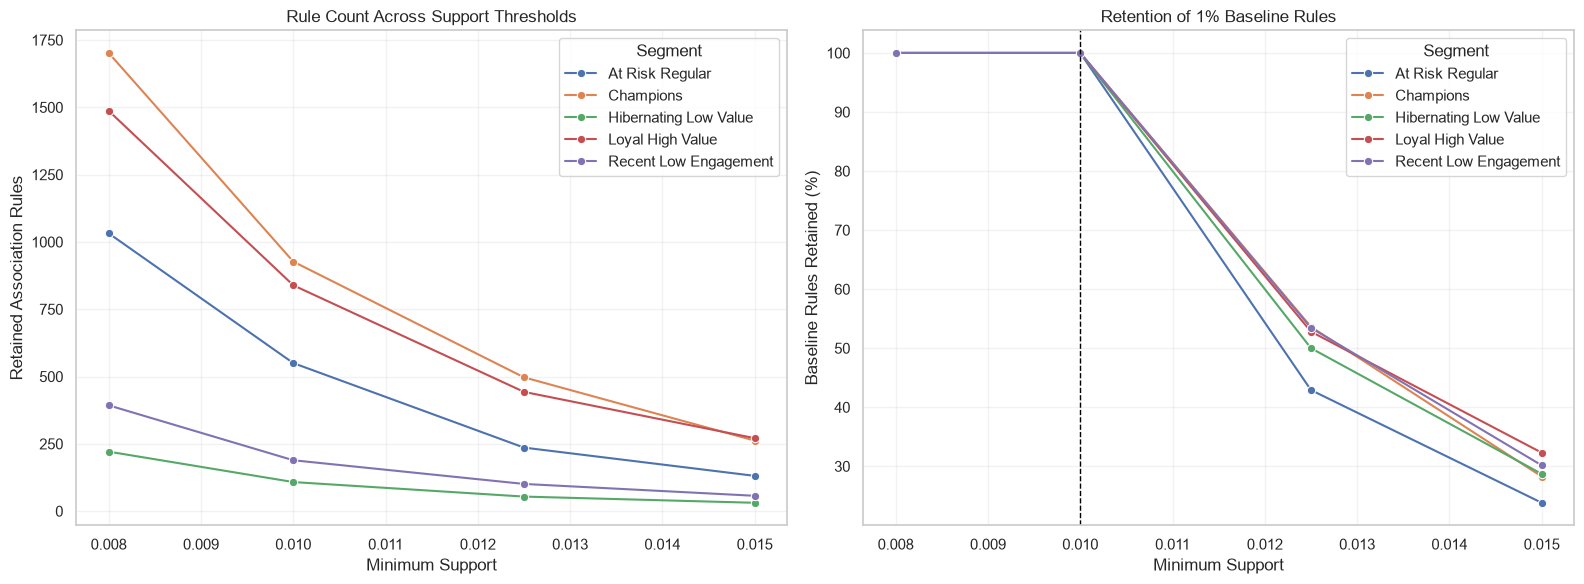

Figure saved: /Users/lakshithadilshan/Documents/online-retail-customer-analytics/outputs/figures/association_rule_support_sensitivity.png


In [23]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

sns.lineplot(
    data=support_sensitivity_summary,
    x="Support_Threshold",
    y="Retained_Rules",
    hue="Segment",
    marker="o",
    ax=axes[0],
)

axes[0].set_title(
    "Rule Count Across Support Thresholds"
)
axes[0].set_xlabel("Minimum Support")
axes[0].set_ylabel("Retained Association Rules")

sns.lineplot(
    data=rule_overlap_summary,
    x="Support_Threshold",
    y="Baseline_Rules_Retained_Percentage",
    hue="Segment",
    marker="o",
    ax=axes[1],
)

axes[1].axvline(
    BASELINE_SUPPORT_THRESHOLD,
    color="black",
    linestyle="--",
    linewidth=1,
    label="1% baseline",
)

axes[1].set_title(
    "Retention of 1% Baseline Rules"
)
axes[1].set_xlabel("Minimum Support")
axes[1].set_ylabel(
    "Baseline Rules Retained (%)"
)

for axis in axes:
    axis.grid(alpha=0.25)

plt.tight_layout()

sensitivity_figure_path = (
    FIGURE_DIR
    / "association_rule_support_sensitivity.png"
)

plt.savefig(
    sensitivity_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved:",
    sensitivity_figure_path,
)

## Sensitivity-Analysis Interpretation

The number of discovered rules decreased consistently as minimum support increased. At the permissive 0.8% threshold, all rules found at the 1% baseline were retained, but the rule pool expanded substantially, increasing the possibility of less generalisable patterns.

At thresholds of 1.25% and 1.5%, only approximately 24%–54% of the baseline rules remained, depending on the segment. Therefore, these stricter thresholds removed many potentially useful segment-specific relationships.

The 1% baseline provides a defensible balance between:

- sufficient invoice occurrence,
- manageable rule volume,
- segment coverage,
- rule reliability,
- and business usefulness.

For final recommendations, an additional minimum support count of 25 invoices is imposed to prevent low-volume relationships from being treated as actionable recommendations.

In [24]:
final_segment_rule_summary = (
    practical_rules
    .groupby("Segment", observed=True)
    .agg(
        Practical_Rules=("Rule", "size"),
        Unique_Antecedents=(
            "Antecedent_StockCodes",
            "nunique",
        ),
        Unique_Consequents=(
            "Consequent_StockCodes",
            "nunique",
        ),
        Median_Support_Count=(
            "Support_Count",
            "median",
        ),
        Median_Support=("support", "median"),
        Median_Confidence=(
            "confidence",
            "median",
        ),
        Median_Lift=("lift", "median"),
        Maximum_Confidence=(
            "confidence",
            "max",
        ),
        Maximum_Lift=("lift", "max"),
    )
    .reset_index()
)

final_segment_rule_summary = (
    segment_transaction_summary[
        [
            "Cluster",
            "Segment",
            "Customers",
            "Invoices",
        ]
    ]
    .merge(
        final_segment_rule_summary,
        on="Segment",
        how="left",
        validate="one_to_one",
    )
    .sort_values("Cluster")
    .reset_index(drop=True)
)

assert len(final_segment_rule_summary) == 5
assert final_segment_rule_summary[
    "Practical_Rules"
].notna().all()

print("Final segment rule summary created.")
display(final_segment_rule_summary)

Final segment rule summary created.


,Cluster,Segment,Customers,Invoices,Practical_Rules,Unique_Antecedents,Unique_Consequents,Median_Support_Count,Median_Support,Median_Confidence,Median_Lift,Maximum_Confidence,Maximum_Lift
0,1,Hibernating Low Value,1136,1365,19,12,9,30.0000,0.0220,0.6944,12.7703,0.9259,25.7937
1,2,Recent Low Engagement,869,1364,26,22,19,31.5000,0.0231,0.5703,12.9218,0.8974,26.3320
2,3,At Risk Regular,1006,3073,550,300,192,37.0000,0.0120,0.5860,18.8331,1.0000,72.6723
3,4,Loyal High Value,965,5417,839,334,182,69.0000,0.0127,0.5586,10.7165,0.9836,70.0420
4,5,Champions,358,7183,927,347,137,91.0000,0.0127,0.5513,9.4065,0.9375,53.8135


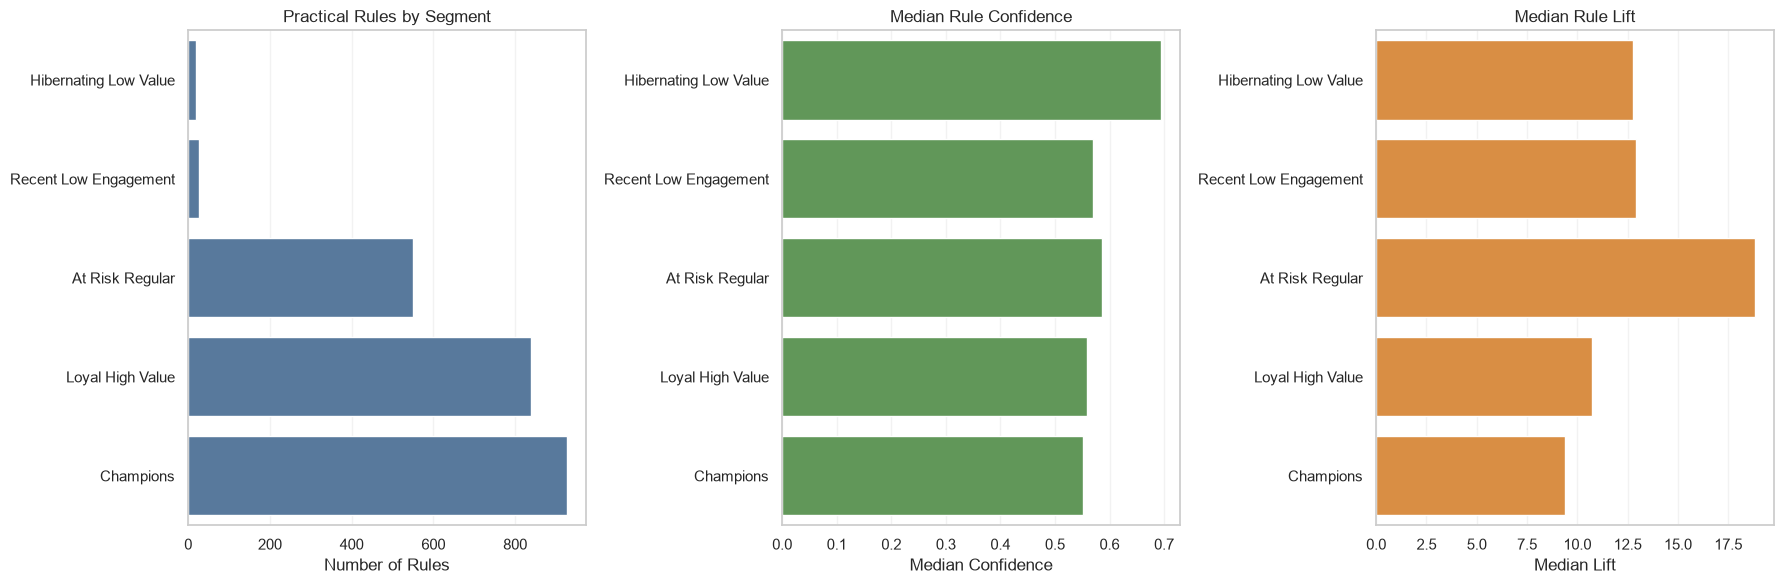

Figure saved: /Users/lakshithadilshan/Documents/online-retail-customer-analytics/outputs/figures/segment_association_rule_comparison.png


In [25]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
)

plot_order = (
    final_segment_rule_summary
    .sort_values("Cluster")["Segment"]
    .tolist()
)

sns.barplot(
    data=final_segment_rule_summary,
    x="Practical_Rules",
    y="Segment",
    order=plot_order,
    color="#4C78A8",
    ax=axes[0],
)

axes[0].set_title(
    "Practical Rules by Segment"
)
axes[0].set_xlabel("Number of Rules")
axes[0].set_ylabel("")

sns.barplot(
    data=final_segment_rule_summary,
    x="Median_Confidence",
    y="Segment",
    order=plot_order,
    color="#59A14F",
    ax=axes[1],
)

axes[1].set_title(
    "Median Rule Confidence"
)
axes[1].set_xlabel("Median Confidence")
axes[1].set_ylabel("")

sns.barplot(
    data=final_segment_rule_summary,
    x="Median_Lift",
    y="Segment",
    order=plot_order,
    color="#F28E2B",
    ax=axes[2],
)

axes[2].set_title("Median Rule Lift")
axes[2].set_xlabel("Median Lift")
axes[2].set_ylabel("")

for axis in axes:
    axis.grid(
        axis="x",
        alpha=0.25,
    )

plt.tight_layout()

rule_comparison_figure_path = (
    FIGURE_DIR
    / "segment_association_rule_comparison.png"
)

plt.savefig(
    rule_comparison_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved:",
    rule_comparison_figure_path,
)

In [26]:
segment_strategy_map = {
    "Hibernating Low Value": {
        "Business_Objective": "Low-cost reactivation",
        "Recommended_Channel": (
            "Email or low-cost digital campaign"
        ),
        "Offer_Strategy": (
            "Use familiar-product bundles and "
            "limited-value win-back offers"
        ),
        "Priority": "Low",
    },
    "Recent Low Engagement": {
        "Business_Objective": (
            "Encourage a second purchase"
        ),
        "Recommended_Channel": (
            "Post-purchase email or website recommendation"
        ),
        "Offer_Strategy": (
            "Recommend complementary products shortly "
            "after the first purchase"
        ),
        "Priority": "High",
    },
    "At Risk Regular": {
        "Business_Objective": (
            "Prevent customer loss"
        ),
        "Recommended_Channel": (
            "Personalised email or direct campaign"
        ),
        "Offer_Strategy": (
            "Use previous product interests to create "
            "targeted reactivation bundles"
        ),
        "Priority": "High",
    },
    "Loyal High Value": {
        "Business_Objective": "Strengthen loyalty",
        "Recommended_Channel": (
            "Loyalty programme and personalised offers"
        ),
        "Offer_Strategy": (
            "Provide cross-sell bundles, early access, "
            "and loyalty rewards"
        ),
        "Priority": "Very High",
    },
    "Champions": {
        "Business_Objective": "Retain and reward",
        "Recommended_Channel": (
            "VIP communication and premium campaigns"
        ),
        "Offer_Strategy": (
            "Offer premium bundles, exclusive access, "
            "and personalised recommendations"
        ),
        "Priority": "Very High",
    },
}

final_recommendations = (
    selected_recommendation_rules[
        [
            "Segment",
            "Recommendation_Rank",
            "Antecedent_StockCodes",
            "Consequent_StockCodes",
            "Antecedent_Products",
            "Consequent_Products",
            "Support_Count",
            "support",
            "confidence",
            "lift",
            "leverage",
            "Rule_Score",
        ]
    ]
    .copy()
)

final_recommendations[
    "Recommendation"
] = (
    "When an invoice contains "
    + final_recommendations[
        "Antecedent_Products"
    ]
    + ", recommend "
    + final_recommendations[
        "Consequent_Products"
    ]
    + "."
)

for strategy_column in [
    "Business_Objective",
    "Recommended_Channel",
    "Offer_Strategy",
    "Priority",
]:
    final_recommendations[strategy_column] = (
        final_recommendations["Segment"].map(
            lambda segment: (
                segment_strategy_map[segment][
                    strategy_column
                ]
            )
        )
    )

final_recommendations = (
    final_recommendations[
        [
            "Segment",
            "Recommendation_Rank",
            "Business_Objective",
            "Antecedent_StockCodes",
            "Antecedent_Products",
            "Consequent_StockCodes",
            "Consequent_Products",
            "Recommendation",
            "Support_Count",
            "support",
            "confidence",
            "lift",
            "leverage",
            "Rule_Score",
            "Recommended_Channel",
            "Offer_Strategy",
            "Priority",
        ]
    ]
    .sort_values(
        ["Segment", "Recommendation_Rank"]
    )
    .reset_index(drop=True)
)

assert len(final_recommendations) == 40
assert final_recommendations.isna().sum().sum() == 0

print(
    "Business recommendations created:",
    len(final_recommendations),
)

display(final_recommendations.head(10))

Business recommendations created: 40


,Segment,Recommendation_Rank,Business_Objective,Antecedent_StockCodes,Antecedent_Products,Consequent_StockCodes,Consequent_Products,Recommendation,Support_Count,support,confidence,lift,leverage,Rule_Score,Recommended_Channel,Offer_Strategy,Priority
0,At Risk Regular,1,Prevent customer loss,22920,HERB MARKER BASIL,22919,HERB MARKER MINT,"When an invoice contains HERB MARKER BASIL, recommend HERB MARKER MINT.",43,0.0140,0.9773,66.7369,0.0138,0.8566,Personalised email or direct campaign,Use previous product interests to create targeted reactivation bundles,High
1,At Risk Regular,2,Prevent customer loss,22920,HERB MARKER BASIL,22918,HERB MARKER PARSLEY,"When an invoice contains HERB MARKER BASIL, recommend HERB MARKER PARSLEY.",43,0.0140,0.9773,66.7369,0.0138,0.8566,Personalised email or direct campaign,Use previous product interests to create targeted reactivation bundles,High
2,At Risk Regular,3,Prevent customer loss,"22918, 22919",HERB MARKER PARSLEY + HERB MARKER MINT,22920,HERB MARKER BASIL,"When an invoice contains HERB MARKER PARSLEY + HERB MARKER MINT, recommend HERB MARKER BASIL.",42,0.0137,0.9767,68.2167,0.0135,0.8485,Personalised email or direct campaign,Use previous product interests to create targeted reactivation bundles,High
3,At Risk Regular,4,Prevent customer loss,"22698, 22699",PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY TEACUP AND SAUCER,22697,GREEN REGENCY TEACUP AND SAUCER,"When an invoice contains PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY TEACUP AND SAUCER, recommend GREEN REGENCY T...",81,0.0264,0.9205,20.2040,0.0251,0.8390,Personalised email or direct campaign,Use previous product interests to create targeted reactivation bundles,High
4,At Risk Regular,5,Prevent customer loss,22917,HERB MARKER ROSEMARY,22916,HERB MARKER THYME,"When an invoice contains HERB MARKER ROSEMARY, recommend HERB MARKER THYME.",40,0.0130,1.0000,69.8409,0.0128,0.8314,Personalised email or direct campaign,Use previous product interests to create targeted reactivation bundles,High
5,At Risk Regular,6,Prevent customer loss,47590A,BLUE HAPPY BIRTHDAY BUNTING,47590B,PINK HAPPY BIRTHDAY BUNTING,"When an invoice contains BLUE HAPPY BIRTHDAY BUNTING, recommend PINK HAPPY BIRTHDAY BUNTING.",77,0.0251,0.8191,25.9510,0.0241,0.8314,Personalised email or direct campaign,Use previous product interests to create targeted reactivation bundles,High
6,At Risk Regular,7,Prevent customer loss,47590B,PINK HAPPY BIRTHDAY BUNTING,47590A,BLUE HAPPY BIRTHDAY BUNTING,"When an invoice contains PINK HAPPY BIRTHDAY BUNTING, recommend BLUE HAPPY BIRTHDAY BUNTING.",77,0.0251,0.7938,25.9510,0.0241,0.8254,Personalised email or direct campaign,Use previous product interests to create targeted reactivation bundles,High
7,At Risk Regular,8,Prevent customer loss,"22697, 22698",GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,"When an invoice contains GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY TEACUP AND SAUCER, recommend ROSES REGENCY T...",81,0.0264,0.8617,18.1371,0.0249,0.8107,Personalised email or direct campaign,Use previous product interests to create targeted reactivation bundles,High
8,Champions,1,Retain and reward,22697,GREEN REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,"When an invoice contains GREEN REGENCY TEACUP AND SAUCER, recommend ROSES REGENCY TEACUP AND SAUCER.",242,0.0337,0.8259,16.9506,0.0317,0.9539,VIP communication and premium campaigns,"Offer premium bundles, exclusive access, and personalised recommendations",Very High
9,Champions,2,Retain and reward,22698,PINK REGENCY TEACUP AND SAUCER,22697,GREEN REGENCY TEACUP AND SAUCER,"When an invoice contains PINK REGENCY TEACUP AND SAUCER, recommend GREEN REGENCY TEACUP AND SAUCER.",197,0.0274,0.8008,19.6322,0.0260,0.9512,VIP communication and premium campaigns,"Offer premium bundles, exclusive access, and personalised recommendations",Very High


In [29]:
documentation_outputs = {
    "association_input_quality_summary.csv": (
        input_quality_summary
    ),
    "segment_basket_quality_summary.csv": (
        basket_quality_summary
    ),
    "segment_frequent_itemset_summary.csv": (
        frequent_itemset_summary
    ),
    "segment_association_rule_summary.csv": (
        final_segment_rule_summary
    ),
    "association_rule_support_sensitivity.csv": (
        support_sensitivity_summary
    ),
    "association_rule_overlap_summary.csv": (
        rule_overlap_summary
    ),
    "segment_product_recommendations.csv": (
        final_recommendations
    ),
}

for filename, output_dataframe in (
    documentation_outputs.items()
):
    output_path = DOCUMENTATION_DIR / filename

    output_dataframe.to_csv(
        output_path,
        index=False,
    )

    reloaded_dataframe = pd.read_csv(
        output_path
    )

    assert len(reloaded_dataframe) == len(
        output_dataframe
    )

    print(
        f"Saved documentation: {filename} "
        f"({len(output_dataframe):,} rows)"
    )

print(
    "All association-mining documentation "
    "outputs passed reload validation."
)

Saved documentation: association_input_quality_summary.csv (3 rows)
Saved documentation: segment_basket_quality_summary.csv (5 rows)
Saved documentation: segment_frequent_itemset_summary.csv (5 rows)
Saved documentation: segment_association_rule_summary.csv (5 rows)
Saved documentation: association_rule_support_sensitivity.csv (20 rows)
Saved documentation: association_rule_overlap_summary.csv (20 rows)
Saved documentation: segment_product_recommendations.csv (40 rows)
All association-mining documentation outputs passed reload validation.


## Final Association-Mining Decision

The final approach uses segment-specific FP-Growth with binary invoice-product baskets.

### Selected configuration

- Algorithm: FP-Growth
- Basket unit: Invoice
- Item identifier: StockCode
- Maximum itemset length: 3
- Adaptive initial support: maximum of 1% or 20 segment invoices
- Initial confidence: 30%
- Initial lift: 1.20
- Practical minimum support count: 25 invoices
- Practical confidence: 40%
- Practical lift: 1.50
- Final recommendations: 8 diverse rules per segment

The selected configuration balances statistical strength, computational feasibility, segment coverage, interpretability, and commercial usefulness. Support-sensitivity analysis showed that 0.8% produced substantially more rules, while stricter thresholds removed many potentially useful relationships. Therefore, the 1% baseline with additional practical quality filtering was retained.

In [30]:
association_mining_summary = pd.DataFrame([
    {
        "Responsible_Member": (
            "Senaratne P.A.R.T. (IT24103526)"
        ),
        "Algorithm": "FP-Growth",
        "Analysis_Level": (
            "Invoice-level product presence"
        ),
        "Segmentation_Input": (
            "KMeans customer segmentation"
        ),
        "Segments": (
            segment_transactions["Segment"].nunique()
        ),
        "Customers": (
            segment_transactions[
                "CustomerID"
            ].nunique()
        ),
        "Segment_Transaction_Rows": len(
            segment_transactions
        ),
        "Segment_Invoices": (
            segment_transactions[
                "InvoiceNo"
            ].nunique()
        ),
        "Unique_StockCodes": (
            segment_transactions[
                "StockCode"
            ].nunique()
        ),
        "Maximum_Itemset_Length": (
            MAXIMUM_ITEMSET_LENGTH
        ),
        "Initial_Minimum_Support": (
            "max(0.01, 20 / segment invoices)"
        ),
        "Initial_Minimum_Confidence": (
            MINIMUM_CONFIDENCE
        ),
        "Initial_Minimum_Lift": MINIMUM_LIFT,
        "Practical_Minimum_Support_Count": (
            PRACTICAL_MINIMUM_SUPPORT_COUNT
        ),
        "Practical_Minimum_Confidence": (
            PRACTICAL_MINIMUM_CONFIDENCE
        ),
        "Practical_Minimum_Lift": (
            PRACTICAL_MINIMUM_LIFT
        ),
        "Initial_Rules_Retained": len(
            all_segment_rules
        ),
        "Practical_Rules_Retained": len(
            practical_rules
        ),
        "Final_Recommendations": len(
            final_recommendations
        ),
        "Sensitivity_Experiments": len(
            support_sensitivity_summary
        ),
        "Selection_Reason": (
            "Balanced support, confidence, lift, "
            "segment coverage, robustness, "
            "interpretability and business usefulness"
        ),
    }
])

assert len(association_mining_summary) == 1
assert (
    association_mining_summary[
        "Final_Recommendations"
    ].iloc[0]
    == 40
)

association_summary_path = (
    DOCUMENTATION_DIR
    / "association_mining_summary.csv"
)

association_mining_summary.to_csv(
    association_summary_path,
    index=False,
)

reloaded_association_summary = pd.read_csv(
    association_summary_path
)

assert len(reloaded_association_summary) == 1

print("Final association-mining summary saved.")
display(association_mining_summary)

Final association-mining summary saved.


,Responsible_Member,Algorithm,Analysis_Level,Segmentation_Input,Segments,Customers,Segment_Transaction_Rows,Segment_Invoices,Unique_StockCodes,Maximum_Itemset_Length,Initial_Minimum_Support,Initial_Minimum_Confidence,Initial_Minimum_Lift,Practical_Minimum_Support_Count,Practical_Minimum_Confidence,Practical_Minimum_Lift,Initial_Rules_Retained,Practical_Rules_Retained,Final_Recommendations,Sensitivity_Experiments,Selection_Reason
0,Senaratne P.A.R.T. (IT24103526),FP-Growth,Invoice-level product presence,KMeans customer segmentation,5,4334,391150,18402,3659,3,"max(0.01, 20 / segment invoices)",0.3000,1.2000,25,0.4000,1.5000,3129,2361,40,20,"Balanced support, confidence, lift, segment coverage, robustness, interpretability and business usefulness"


In [31]:
association_output_paths = [
    DOCUMENTATION_DIR
    / "association_input_quality_summary.csv",

    DOCUMENTATION_DIR
    / "segment_basket_quality_summary.csv",

    DOCUMENTATION_DIR
    / "segment_frequent_itemset_summary.csv",

    DOCUMENTATION_DIR
    / "segment_association_rule_summary.csv",

    DOCUMENTATION_DIR
    / "association_rule_support_sensitivity.csv",

    DOCUMENTATION_DIR
    / "association_rule_overlap_summary.csv",

    DOCUMENTATION_DIR
    / "segment_product_recommendations.csv",

    DOCUMENTATION_DIR
    / "association_mining_summary.csv",

    FIGURE_DIR
    / "association_rule_support_sensitivity.png",

    FIGURE_DIR
    / "segment_association_rule_comparison.png",
]

missing_output_paths = [
    str(output_path)
    for output_path in association_output_paths
    if not output_path.exists()
]

assert not missing_output_paths, (
    "Missing association-mining outputs:\n"
    + "\n".join(missing_output_paths)
)

association_output_fingerprints = pd.DataFrame([
    {
        "Filename": output_path.name,
        "Relative_Path": str(
            output_path.relative_to(PROJECT_ROOT)
        ),
        "File_Type": (
            output_path.suffix.lower()
            .replace(".", "")
        ),
        "File_Size_MB": (
            output_path.stat().st_size
            / (1024 ** 2)
        ),
        "SHA256": calculate_sha256(output_path),
        "Produced_By": (
            "Senaratne P.A.R.T. (IT24103526)"
        ),
        "Purpose": (
            "Segment-specific association mining "
            "evidence and recommendations"
        ),
    }
    for output_path in association_output_paths
])

assert len(association_output_fingerprints) == 10
assert (
    association_output_fingerprints[
        "SHA256"
    ].str.len().eq(64).all()
)

fingerprint_output_path = (
    DOCUMENTATION_DIR
    / "association_output_fingerprints.csv"
)

association_output_fingerprints.to_csv(
    fingerprint_output_path,
    index=False,
)

reloaded_fingerprints = pd.read_csv(
    fingerprint_output_path
)

assert len(reloaded_fingerprints) == 10

print(
    "Association output fingerprints saved:",
    len(association_output_fingerprints),
)

display(association_output_fingerprints)

Association output fingerprints saved: 10


,Filename,Relative_Path,File_Type,File_Size_MB,SHA256,Produced_By,Purpose
0,association_input_quality_summary.csv,documentation/association_input_quality_summary.csv,csv,0.0003,e85d9209354eabb7dd3c70c661e90dda19d2ea24ffeb88d5ef85e4950789e37d,Senaratne P.A.R.T. (IT24103526),Segment-specific association mining evidence and recommendations
1,segment_basket_quality_summary.csv,documentation/segment_basket_quality_summary.csv,csv,0.0004,104b8659fb772e0d55b3e67ec490e25f7414bb207acfe72d9b1d563c6b7ecda3,Senaratne P.A.R.T. (IT24103526),Segment-specific association mining evidence and recommendations
2,segment_frequent_itemset_summary.csv,documentation/segment_frequent_itemset_summary.csv,csv,0.0004,903c9ab3f7e2f16fe6b0050b77b9c83dab85d799ad771a51498662c543839ea2,Senaratne P.A.R.T. (IT24103526),Segment-specific association mining evidence and recommendations
3,segment_association_rule_summary.csv,documentation/segment_association_rule_summary.csv,csv,0.0008,55b229b691768ab5c61687635209655a8c21245622829588a04b04c367f4401b,Senaratne P.A.R.T. (IT24103526),Segment-specific association mining evidence and recommendations
4,association_rule_support_sensitivity.csv,documentation/association_rule_support_sensitivity.csv,csv,0.0018,d6b28f6b7abf28f302b717e44f85d4f5e3874bf3105cdf0cc00c513b13760e30,Senaratne P.A.R.T. (IT24103526),Segment-specific association mining evidence and recommendations
5,association_rule_overlap_summary.csv,documentation/association_rule_overlap_summary.csv,csv,0.0013,5a356035fab5e16679982a915ea7da0f84f211be6e4e99c6631e5ba32cf8f5be,Senaratne P.A.R.T. (IT24103526),Segment-specific association mining evidence and recommendations
6,segment_product_recommendations.csv,documentation/segment_product_recommendations.csv,csv,0.0168,cc58483dc392e5f2462fe407686a806cb55aab5916e3e701ca754d459fc20a20,Senaratne P.A.R.T. (IT24103526),Segment-specific association mining evidence and recommendations
7,association_mining_summary.csv,documentation/association_mining_summary.csv,csv,0.0007,a59b7a08a5845bf394030cb666cd4afdc3127aa5019b07ed493b5b25467b2c91,Senaratne P.A.R.T. (IT24103526),Segment-specific association mining evidence and recommendations
8,association_rule_support_sensitivity.png,outputs/figures/association_rule_support_sensitivity.png,png,0.4767,ccccf09bb645999121207daf669f2c4825d97d58c9ef85e18bc93e6ad2fbe209,Senaratne P.A.R.T. (IT24103526),Segment-specific association mining evidence and recommendations
9,segment_association_rule_comparison.png,outputs/figures/segment_association_rule_comparison.png,png,0.1465,1d46fb3707329424ec33f375e228acc955086df006daa4f5b413dc732bb0d742,Senaratne P.A.R.T. (IT24103526),Segment-specific association mining evidence and recommendations


In [32]:
required_documentation_files = [
    *association_output_paths[:8],
    fingerprint_output_path,
]

assert all(
    file_path.exists()
    for file_path in required_documentation_files
)

assert len(segment_assignments) == 4334
assert segment_assignments[
    "CustomerID"
].is_unique

assert segment_transactions[
    "Segment"
].nunique() == 5

assert len(final_segment_rule_summary) == 5
assert len(final_recommendations) == 40

assert (
    final_recommendations
    .groupby("Segment")
    .size()
    .eq(8)
    .all()
)

assert final_recommendations[
    [
        "Antecedent_Products",
        "Consequent_Products",
        "confidence",
        "lift",
        "Recommendation",
    ]
].notna().all().all()

assert (
    final_recommendations["confidence"]
    >= PRACTICAL_MINIMUM_CONFIDENCE
).all()

assert (
    final_recommendations["lift"]
    >= PRACTICAL_MINIMUM_LIFT
).all()

assert (
    final_recommendations["Support_Count"]
    >= PRACTICAL_MINIMUM_SUPPORT_COUNT
).all()

print(
    "All association-mining outputs passed "
    "final handover validation."
)

print(
    "Customers analysed:",
    f"{segment_assignments['CustomerID'].nunique():,}",
)

print(
    "Segments analysed:",
    segment_transactions["Segment"].nunique(),
)

print(
    "Practical rules evaluated:",
    f"{len(practical_rules):,}",
)

print(
    "Final recommendations:",
    len(final_recommendations),
)

print(
    "Responsible member:",
    "Senaratne P.A.R.T. (IT24103526)",
)

All association-mining outputs passed final handover validation.
Customers analysed: 4,334
Segments analysed: 5
Practical rules evaluated: 2,361
Final recommendations: 40
Responsible member: Senaratne P.A.R.T. (IT24103526)
